In [1]:
import pandas as pd
df_csv=pd.read_csv("complete_dataset_with_all_features.csv")
print(df_csv.head())

                     keyword                                        title  \
0            air fryer India               Nike air fryer India Model 114   
1  microwave oven convection  Philips microwave oven convection Model 363   
2            air fryer India               Dell air fryer India Model 406   
3   power bank fast charging      Nike power bank fast charging Model 363   
4          men running shoes          Samsung men running shoes Model 836   

   price  rating  reviews          platform       delivery    brand  \
0  509.0     3.8     3324  reliance digital         2 days     Nike   
1  545.0     4.5     3336  reliance digital         2 days  Philips   
2  580.0     5.0     4288  reliance digital  free delivery     Dell   
3  702.0     4.5     1477          flipkart         2 days     Nike   
4  712.0     4.6      819          flipkart         2 days  Samsung   

  price_range  popularity_score  raw_price  discount  
0  low-Budget         30.815055      509.0         0  


In [2]:
import sqlite3

# Define the database name
db_name = 'products.db'

# Create a connection to the database (it will create the database file if it doesn't exist)
conn = sqlite3.connect(db_name)

# Use the to_sql method to write the DataFrame to a SQL table
# if_exists='replace' will drop the table and recreate it if it already exists
df_csv.to_sql('products_data', conn, if_exists='replace', index=False)

print(f"Table 'products_data' created in {db_name} from df_csv.")

# Verify by reading the table back into a new DataFrame
df_from_db = pd.read_sql_query("SELECT * FROM products_data LIMIT 5", conn)
display(df_from_db)

# Close the connection
conn.close()

Table 'products_data' created in products.db from df_csv.


,keyword,title,price,rating,reviews,platform,delivery,brand,price_range,popularity_score,raw_price,discount
0,air fryer India,Nike air fryer India Model 114,509.0,3.8,3324,reliance digital,2 days,Nike,low-Budget,30.815055,509.0,0
1,microwave oven convection,Philips microwave oven convection Model 363,545.0,4.5,3336,reliance digital,2 days,Philips,low-Budget,36.507724,545.0,0
2,air fryer India,Dell air fryer India Model 406,580.0,5.0,4288,reliance digital,free delivery,Dell,low-Budget,41.819044,580.0,0
3,power bank fast charging,Nike power bank fast charging Model 363,702.0,4.5,1477,flipkart,2 days,Nike,low-Budget,32.843003,702.0,0
4,men running shoes,Samsung men running shoes Model 836,712.0,4.6,819,flipkart,2 days,Samsung,low-Budget,30.862800,712.0,0


# 1.Overview

## KPIs

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the database name
db_name = 'products.db'

# Create a connection to the database
conn = sqlite3.connect(db_name)

# Load the 'products_data' table into a DataFrame
df_db = pd.read_sql_query("SELECT * FROM products_data", conn)

# Close the connection
conn.close()

# Calculate KPIs
total_products = len(df_db)
avg_price = df_db['price'].mean()
avg_rating = df_db['rating'].mean()
total_reviews = df_db['reviews'].sum()

print(f"Total Products: {total_products}")
print(f"Average Price: {avg_price:.2f}")
print(f"Average Rating: {avg_rating:.2f}")
print(f"Total Reviews: {total_reviews}")

Total Products: 2392
Average Price: 16639.26
Average Rating: 4.08
Total Reviews: 45366781


## Charts

### Price Distribution (Histogram)

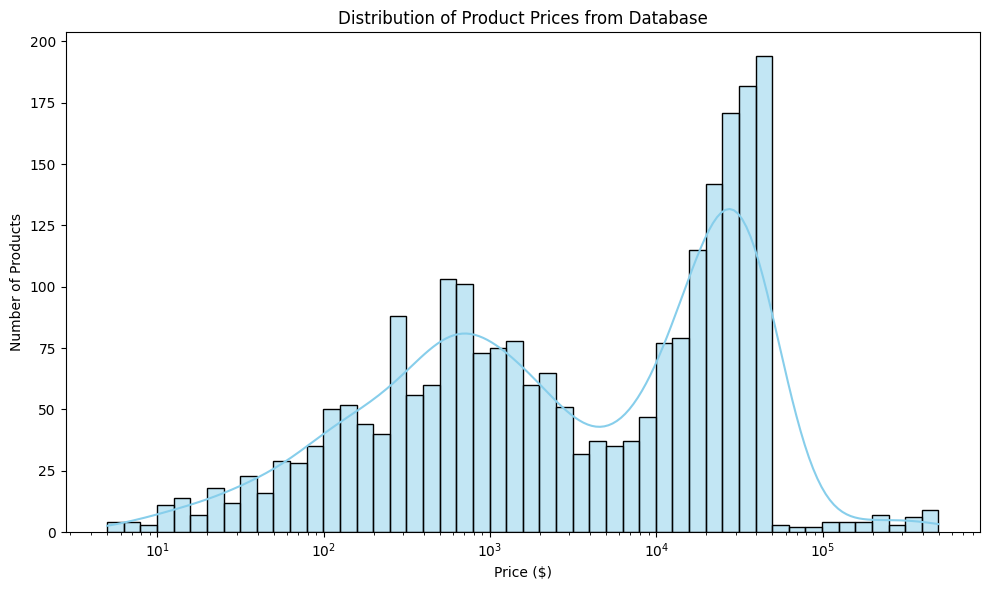

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_db['price'], bins=50, log_scale=True, kde=True, color='skyblue')
plt.title('Distribution of Product Prices from Database')
plt.xlabel('Price ($)')
plt.ylabel('Number of Products')
plt.tight_layout()
plt.show()

### Products per Keyword (Bar Chart)

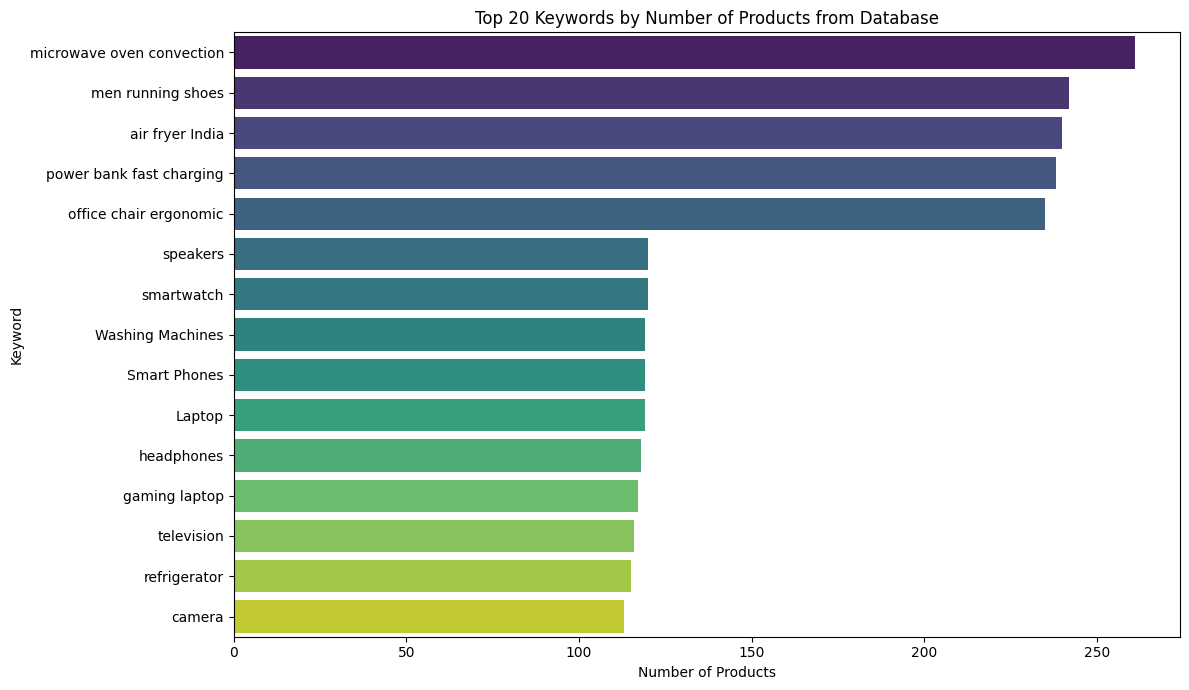

In [ ]:
# Calculate the count of products per keyword
products_per_keyword = df_db['keyword'].value_counts().reset_index()
products_per_keyword.columns = ['Keyword', 'Product Count']

# Plotting the distribution of products per keyword (top 20 for readability)
plt.figure(figsize=(12, 7))
sns.barplot(x='Product Count', y='Keyword', hue='Keyword', data=products_per_keyword.head(20), palette='viridis', legend=False)
plt.title('Top 20 Keywords by Number of Products from Database')
plt.xlabel('Number of Products')
plt.ylabel('Keyword')
plt.tight_layout()
plt.show()

### Platform Share (Pie Chart)

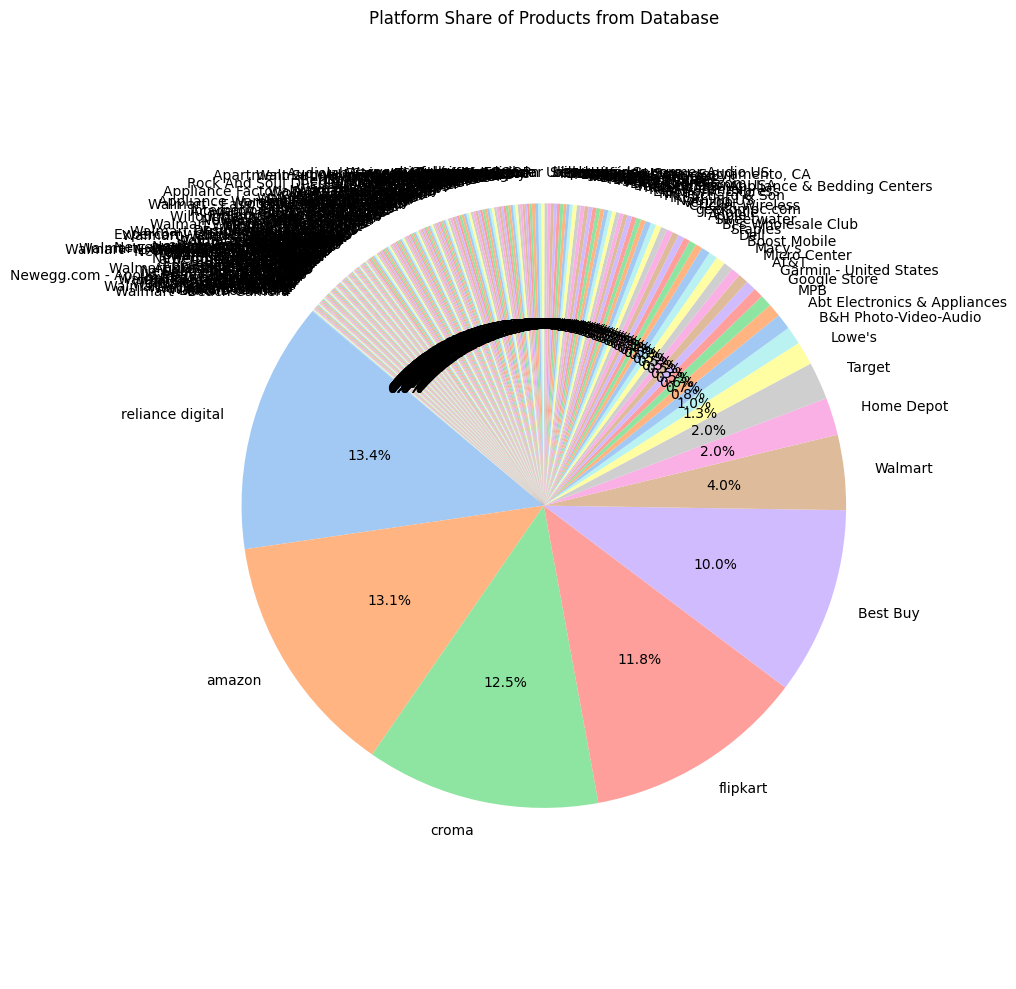

In [ ]:
# Calculate the share of products per platform
platform_share = df_db['platform'].value_counts()

plt.figure(figsize=(10, 10))
plt.pie(platform_share, labels=platform_share.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Platform Share of Products from Database')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

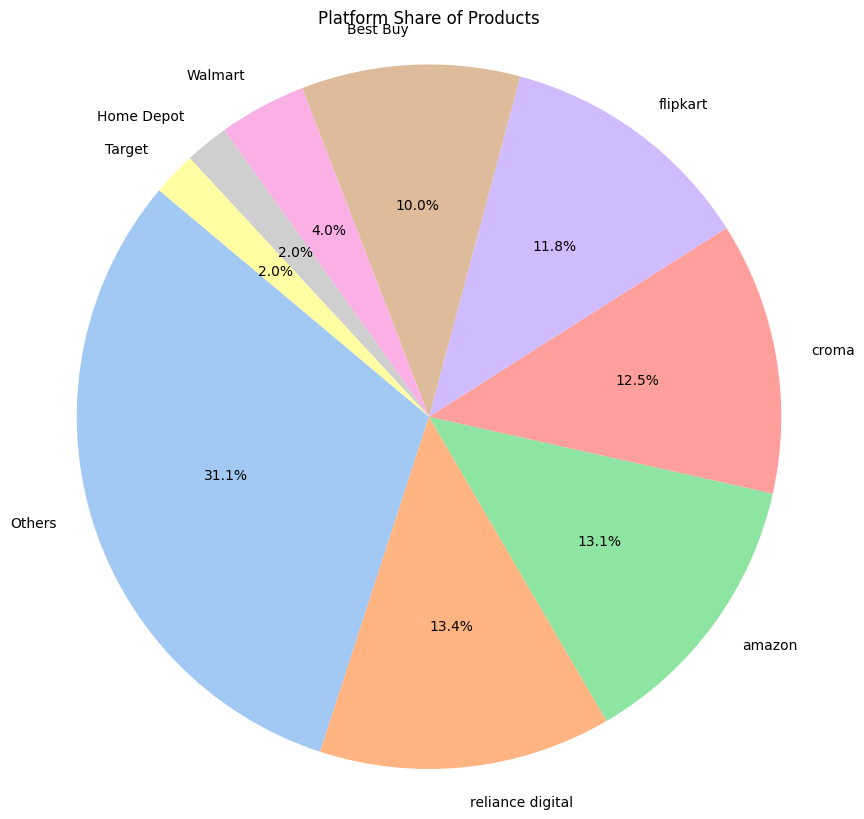

In [ ]:
platform_share = (
    df_db['platform']
    .value_counts(normalize=True) * 100
)

# Keep platforms with >= 2%
major_platforms = platform_share[platform_share >= 2]

# Combine remaining platforms
others_share = platform_share[platform_share < 2].sum()

plot_data = major_platforms.copy()
plot_data['Others'] = others_share

# Sort descending
plot_data = plot_data.sort_values(ascending=False)

plt.figure(figsize=(10, 10))

plt.pie(
    plot_data,
    labels=plot_data.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('pastel', len(plot_data))
)

plt.title('Platform Share of Products')
plt.axis('equal')

plt.show()

## 2. Brand Insights

This section analyzes performance, popularity, and presence across different product brands.

In [ ]:
df_db1 = df_db[df_db['brand'] != 'Unknown']

In [ ]:
# Calculate Brand KPIs
top_brand = df_db1['brand'].value_counts().idxmax()
top_brand_count = df_db1['brand'].value_counts().max()
avg_popularity = df_db1['popularity_score'].mean()

print(f"Top Brand by Product Count: {top_brand} ({top_brand_count} products)")
print(f"Average Popularity Score: {avg_popularity:.2f}")

Top Brand by Product Count: Samsung (251 products)
Average Popularity Score: 32.30


### Brand vs Product Count
We visualize the distribution of products across the top 20 brands.

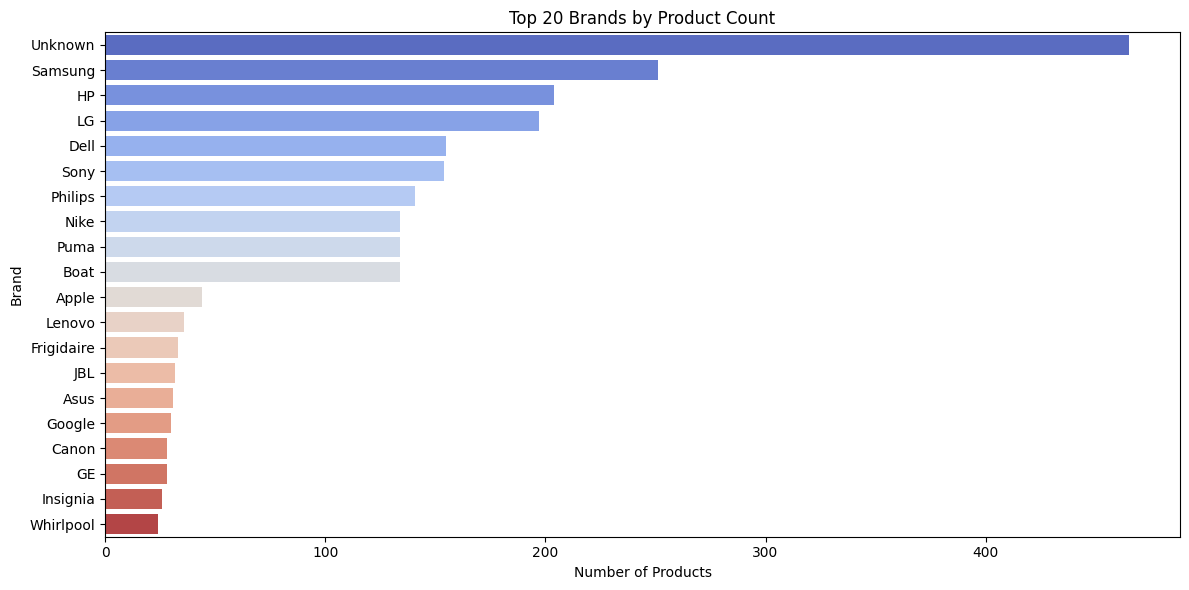

In [ ]:
brand_counts = df_db['brand'].value_counts().reset_index()
brand_counts.columns = ['Brand', 'Product Count']

plt.figure(figsize=(12, 6))
sns.barplot(x='Product Count', y='Brand', hue='Brand', data=brand_counts.head(20), palette='coolwarm', legend=False)
plt.title('Top 20 Brands by Product Count')
plt.xlabel('Number of Products')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()

### Brand vs Average Rating
We analyze the average customer rating for the top 20 brands (with at least 5 products for statistical significance).

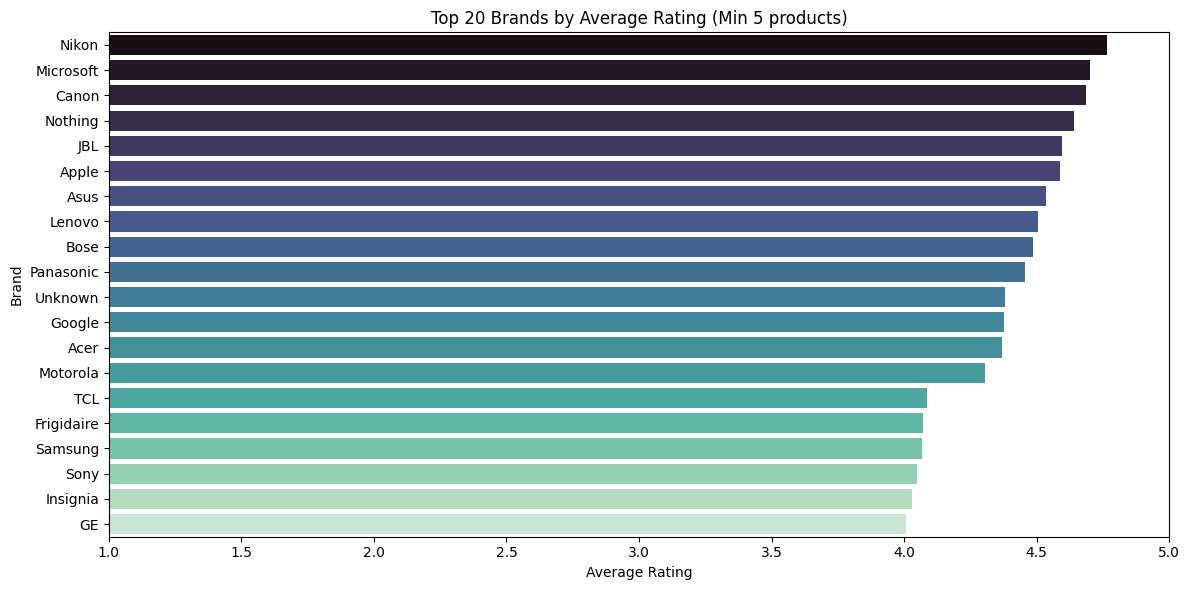

In [ ]:
# Filter brands with at least 5 products
brand_min_counts = df_db['brand'].value_counts()
significant_brands = brand_min_counts[brand_min_counts >= 5].index

brand_ratings = (
    df_db[df_db['brand'].isin(significant_brands)]
    .groupby('brand')['rating']
    .mean()
    .reset_index()
    .sort_values(by='rating', ascending=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(x='rating', y='brand', hue='brand', data=brand_ratings.head(20), palette='mako', legend=False)
plt.title('Top 20 Brands by Average Rating (Min 5 products)')
plt.xlabel('Average Rating')
plt.ylabel('Brand')
plt.xlim(1, 5)
plt.tight_layout()
plt.show()

### Top Brands in Top 10 Positions
We inspect which brands feature most frequently in the top 10 positions based on popularity score.

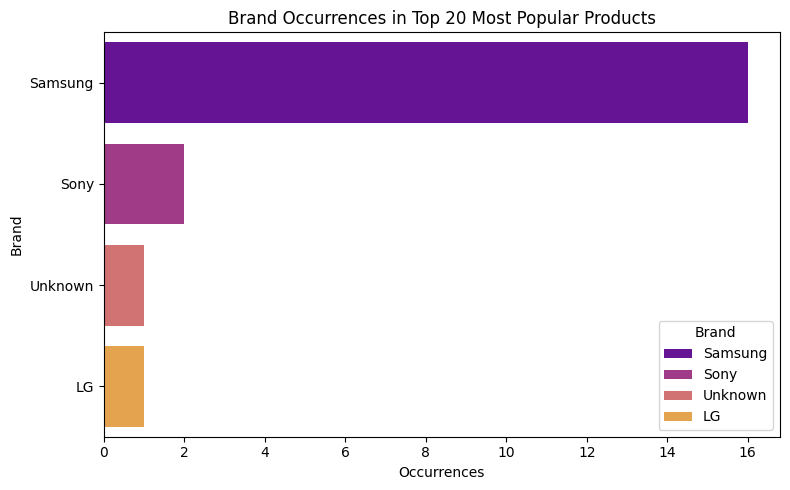

In [ ]:
top_20_products = df_db.nlargest(20, 'popularity_score')
top_20_brands = top_20_products['brand'].value_counts().reset_index()
top_20_brands.columns = ['Brand', 'Count in Top 20']

plt.figure(figsize=(8, 5))
sns.barplot(x='Count in Top 20', y='Brand', hue='Brand', data=top_20_brands, palette='plasma', legend=True)
plt.title('Brand Occurrences in Top 20 Most Popular Products')
plt.xlabel('Occurrences')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()

## 3.Pricing Analysis

This section deep dives into price ranges, discount metrics, and explores how pricing relates to other product features such as user rating and popularity.

In [ ]:
# Calculate Pricing KPIs
avg_price_val = df_db['price'].mean()
max_price_val = df_db['price'].max()

# Assuming a product is discounted if the 'discount' column is greater than 0
if 'discount' in df_db.columns:
    pct_discounted = (df_db['discount'] > 0).mean() * 100
else:
    pct_discounted = 0.0

print(f"Average Price: ${avg_price_val:.2f}")
print(f"Maximum Price: ${max_price_val:.2f}")
print(f"Percentage of Discounted Products: {pct_discounted:.2f}%")

Average Price: $16639.26
Maximum Price: $498050.00
Percentage of Discounted Products: 0.00%


### Price Distribution
We analyze the overall price distribution of products using a histogram with a density estimate.

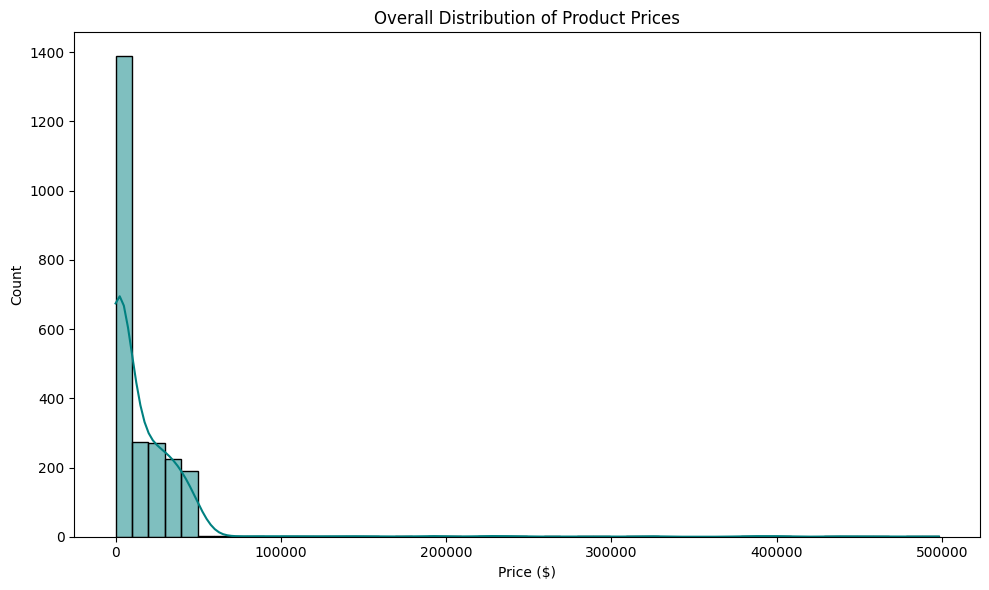

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_db['price'], bins=50, kde=True, color='teal')
plt.title('Overall Distribution of Product Prices')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Price vs. Popularity Score
We inspect if higher-priced products tend to correlate with different ranges of popularity scores.

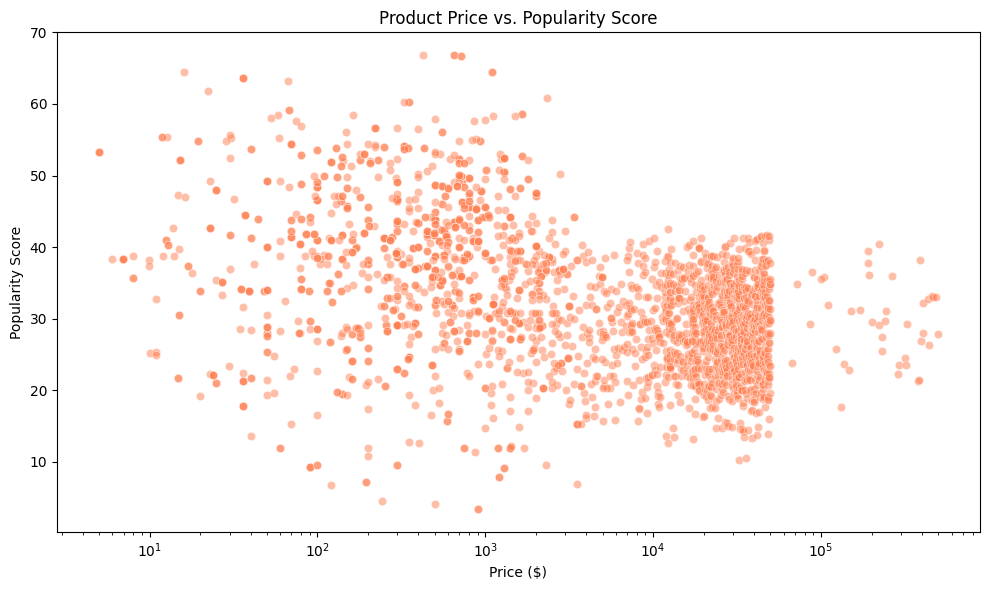

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_db, x='price', y='popularity_score', alpha=0.5, color='coral')
plt.title('Product Price vs. Popularity Score')
plt.xlabel('Price ($)')
plt.ylabel('Popularity Score')
plt.xscale('log') # Using a log scale for better visualization of price spread
plt.tight_layout()
plt.show()

### Price vs. Rating
We map ratings against product prices to see if expensive products receive higher reviews and ratings from buyers.

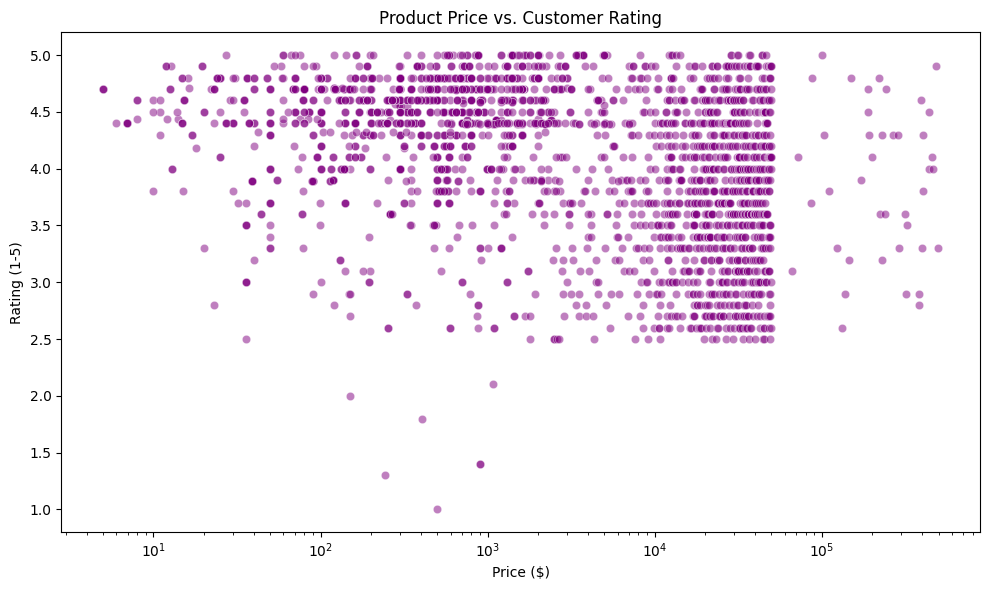

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_db, x='price', y='rating', alpha=0.5, color='purple')
plt.title('Product Price vs. Customer Rating')
plt.xlabel('Price ($)')
plt.ylabel('Rating (1-5)')
plt.xscale('log')
plt.tight_layout()
plt.show()

## 4. Platform Analysis

This section explores how product metrics differ across various retail platforms.

In [ ]:
# Calculate Platform KPIs
total_platforms = df_db['platform'].nunique()

# Group by platform to find average ratings
platform_avg_rating = df_db.groupby('platform')['rating'].mean()
best_platform = platform_avg_rating.idxmax()
best_platform_rating = platform_avg_rating.max()

print(f"Total Platforms: {total_platforms}")
print(f"Best Platform (Highest Avg Rating): {best_platform} ({best_platform_rating:.2f})")

Total Platforms: 251
Best Platform (Highest Avg Rating): Academy Sports + Outdoors (5.00)


### Platform vs Product Count
We visualize the number of products listed on each platform.

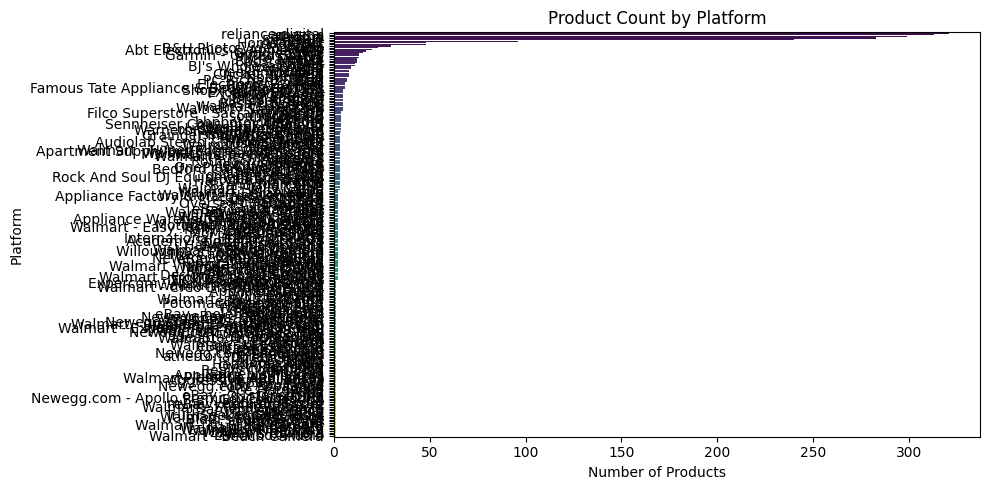

In [ ]:
platform_counts = df_db['platform'].value_counts().reset_index()
platform_counts.columns = ['Platform', 'Product Count']

plt.figure(figsize=(10, 5))
sns.barplot(x='Product Count', y='Platform', hue='Platform', data=platform_counts, palette='viridis', legend=False)
plt.title('Product Count by Platform')
plt.xlabel('Number of Products')
plt.ylabel('Platform')
plt.tight_layout()
plt.show()

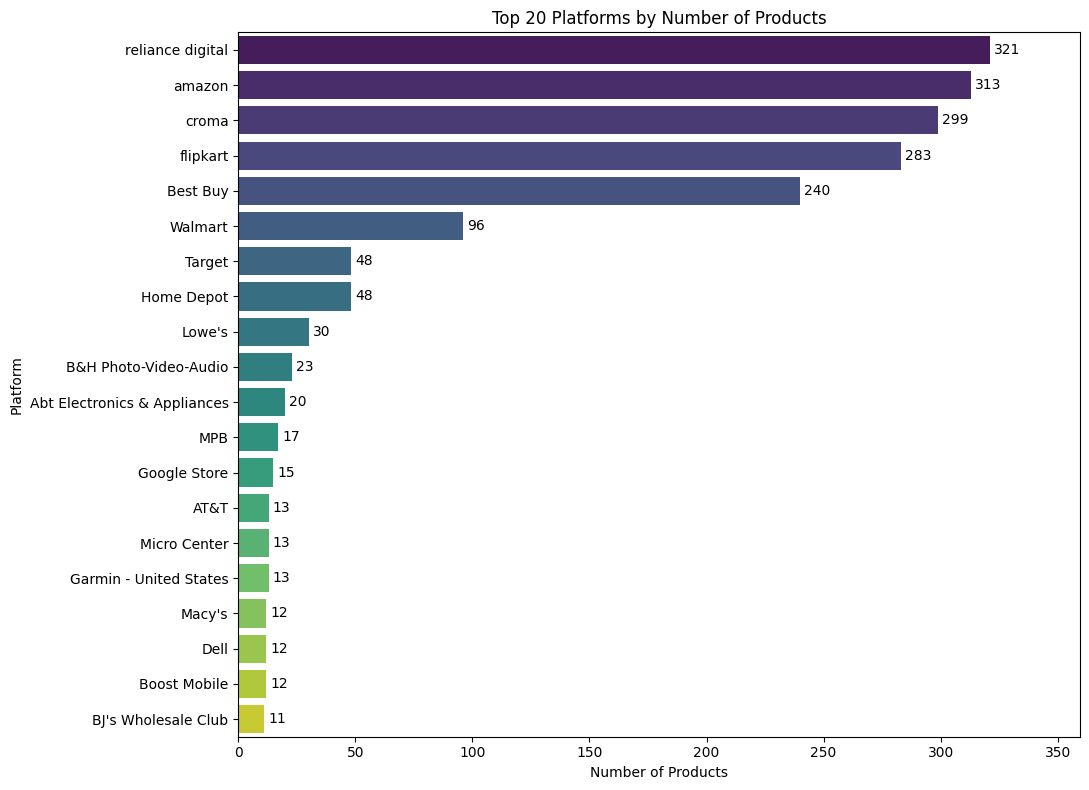

In [ ]:
# Calculate the number of products on each platform
platform_counts = (
    df_db.groupby('platform')
    .agg(
        product_count=('title', 'size')
    )
    .reset_index()
)

# Select the top 20 platforms by product count
top_20_platform_counts = (
    platform_counts
    .sort_values(
        by='product_count',
        ascending=False
    )
    .head(20)
)

# Plot the top 20 platforms
plt.figure(figsize=(11, 8))

ax = sns.barplot(
    data=top_20_platform_counts,
    x='product_count',
    y='platform',
    hue='platform',
    palette='viridis',
    legend=False
)

plt.title('Top 20 Platforms by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Platform')

# Add product-count labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        padding=3
    )

# Add some space for the labels
plt.xlim(
    0,
    top_20_platform_counts['product_count'].max() * 1.12
)

plt.tight_layout()
plt.show()



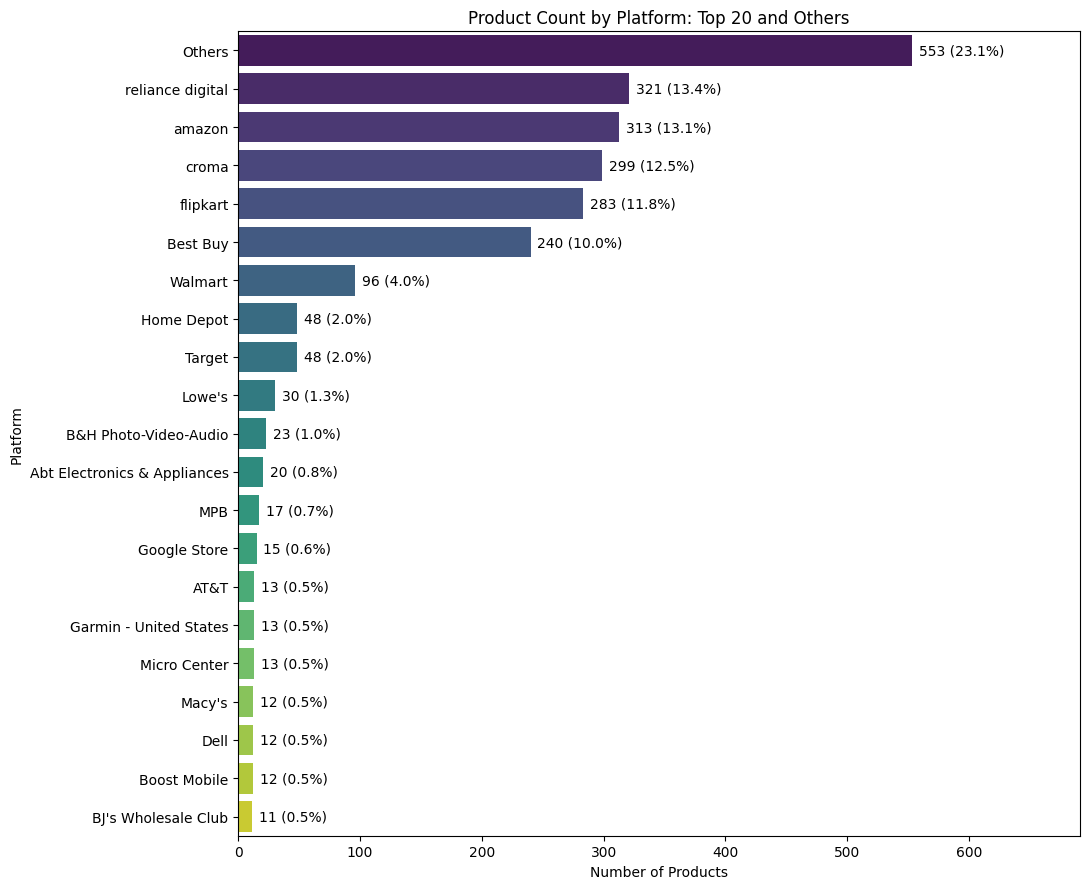

In [ ]:
# Calculate the number of products on each platform
platform_counts = (
    df_db.groupby('platform')
    .agg(
        product_count=('title', 'size')
    )
    .reset_index()
    .sort_values(
        by='product_count',
        ascending=False
    )
)

# Select top 20
top_20_platform_counts = platform_counts.head(20).copy()

# Sum the counts of all remaining platforms
others_count = (
    platform_counts
    .iloc[20:]['product_count']
    .sum()
)

# Create Others row
others = pd.DataFrame({
    'platform': ['Others'],
    'product_count': [others_count]
})

# Combine top 20 and Others
plot_data = pd.concat(
    [top_20_platform_counts, others],
    ignore_index=True
)

plot_data = plot_data.sort_values(
    by='product_count',
    ascending=False
)

# Calculate percentage share
plot_data['percentage'] = (
    plot_data['product_count']
    / plot_data['product_count'].sum()
    * 100
)

plt.figure(figsize=(11, 9))

ax = sns.barplot(
    data=plot_data,
    x='product_count',
    y='platform',
    hue='platform',
    palette='viridis',
    legend=False
)

plt.title('Product Count by Platform: Top 20 and Others')
plt.xlabel('Number of Products')
plt.ylabel('Platform')

# Add both count and percentage
for patch, count, percentage in zip(
    ax.patches,
    plot_data['product_count'],
    plot_data['percentage']
):
    ax.annotate(
        f'{count:,} ({percentage:.1f}%)',
        xy=(
            patch.get_width(),
            patch.get_y() + patch.get_height() / 2
        ),
        xytext=(5, 0),
        textcoords='offset points',
        va='center'
    )

plt.xlim(
    0,
    plot_data['product_count'].max() * 1.25
)

plt.tight_layout()
plt.show()


### Platform vs Average Price
We analyze whether some platforms tend to have higher or lower priced products on average.

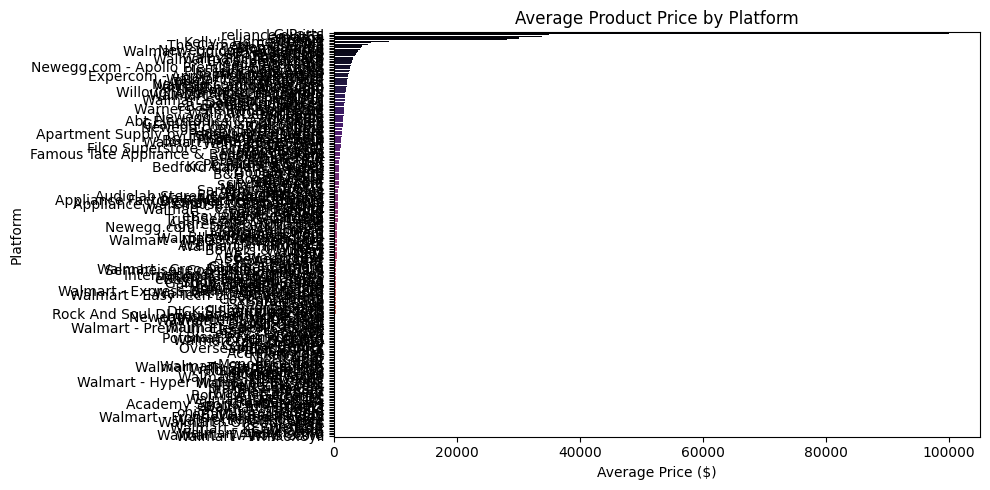

In [ ]:
platform_prices = df_db.groupby('platform')['price'].mean().reset_index().sort_values(by='price', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='price', y='platform', hue='platform', data=platform_prices, palette='magma', legend=False)
plt.title('Average Product Price by Platform')
plt.xlabel('Average Price ($)')
plt.ylabel('Platform')
plt.tight_layout()
plt.show()

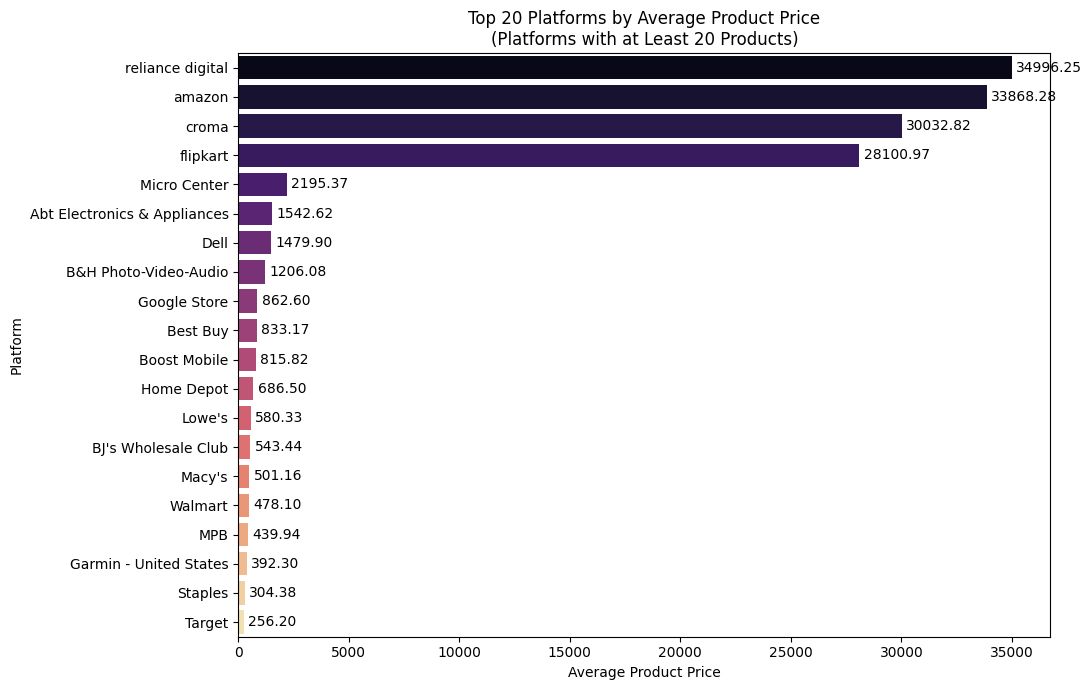

In [ ]:
# Platform-level price statistics
platform_stats = (
    df_db.groupby('platform')
    .agg(
        average_price=('price', 'mean'),
        median_price=('price', 'median'),
        product_count=('price', 'size')
    )
    .reset_index()
)

# Retain platforms with at least 10 products
platform_stats_filtered = (
    platform_stats[
        platform_stats['product_count'] >= 10
    ]
    .sort_values(
        by='average_price',
        ascending=False
    )
    .head(20)
)

plt.figure(figsize=(11, 7))

ax = sns.barplot(
    data=platform_stats_filtered,
    x='average_price',
    y='platform',
    hue='platform',
    palette='magma',
    legend=False
)

plt.title(
    'Top 20 Platforms by Average Product Price\n'
    '(Platforms with at Least 20 Products)'
)
plt.xlabel('Average Product Price')
plt.ylabel('Platform')

# Add average-price labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        padding=3
    )

plt.tight_layout()
plt.show()

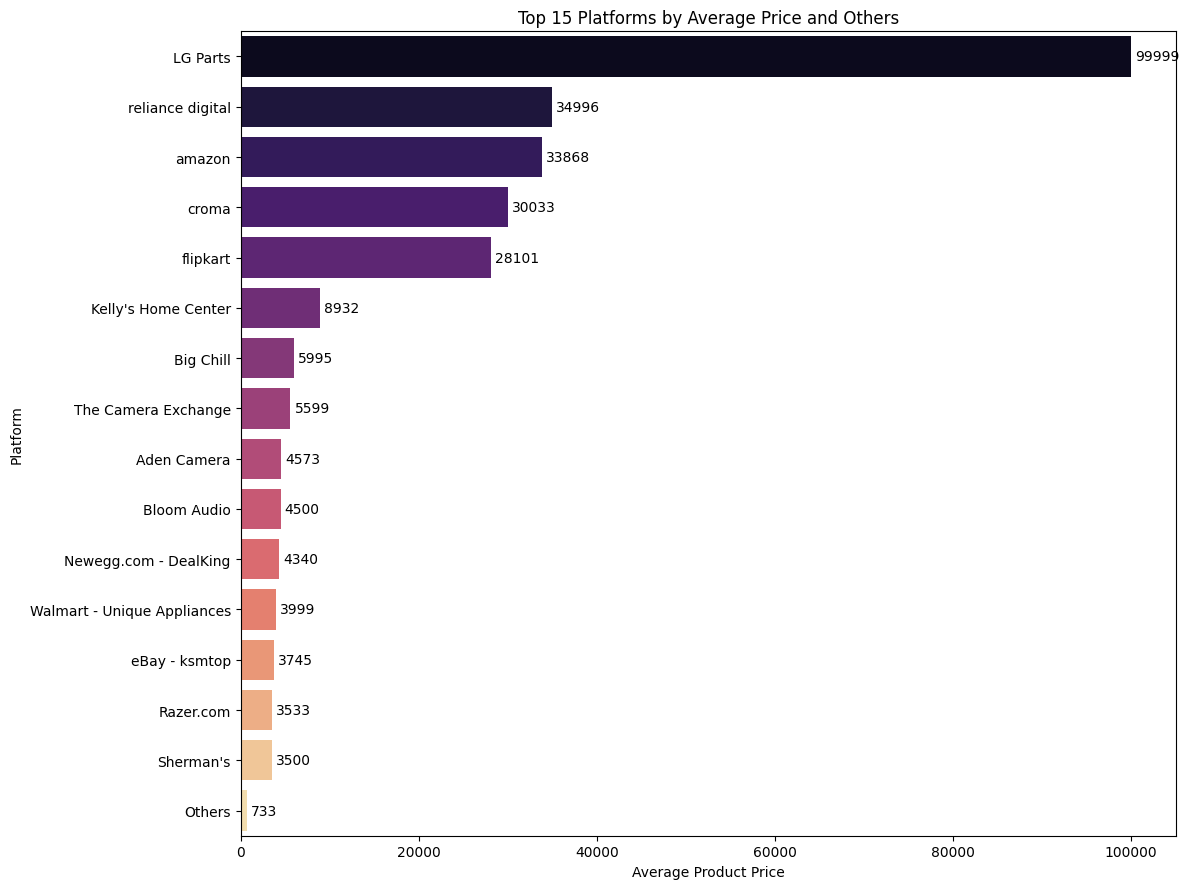

In [ ]:
# Select top 15 platforms by average price
top_15_platforms = (
    platform_stats
    .sort_values(
        by='average_price',
        ascending=False
    )
    .head(15)
)

# Remaining platforms
other_rows = df_db[
    ~df_db['platform'].isin(top_15_platforms['platform'])
]

others = pd.DataFrame({
    'platform': ['Others'],
    'average_price': [other_rows['price'].mean()],
    'median_price': [other_rows['price'].median()],
    'product_count': [len(other_rows)]
})

plot_data = pd.concat(
    [top_15_platforms, others],
    ignore_index=True
)

plot_data = plot_data.sort_values(
    by='average_price',
    ascending=False
)

plt.figure(figsize=(12, 9))

ax = sns.barplot(
    data=plot_data,
    x='average_price',
    y='platform',
    hue='platform',
    palette='magma',
    legend=False
)

plt.title('Top 15 Platforms by Average Price and Others')
plt.xlabel('Average Product Price')
plt.ylabel('Platform')

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f',
        padding=3
    )

plt.tight_layout()
plt.show()



### Platform vs Average Rating
We compare the overall customer satisfaction level (average rating) across different platforms.

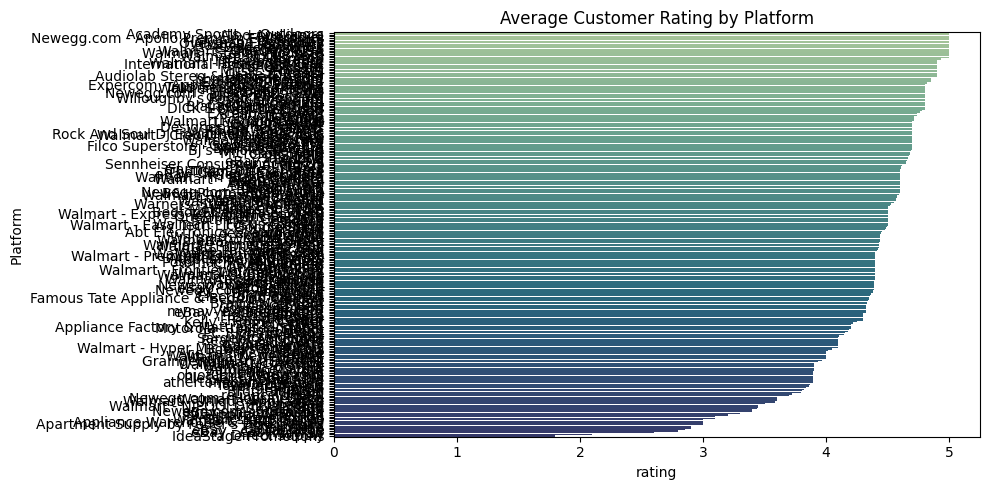

In [ ]:
platform_ratings_df = df_db.groupby('platform')['rating'].mean().reset_index().sort_values(by='rating', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='rating', y='platform', hue='platform', data=platform_ratings_df, palette='crest', legend=False)
plt.title('Average Customer Rating by Platform')
plt.xlabel('Average Rating (1-5)')
plt.ylabel('Platform')
plt.xlim(1, 5)
plt.tight_layout()
plt.show()

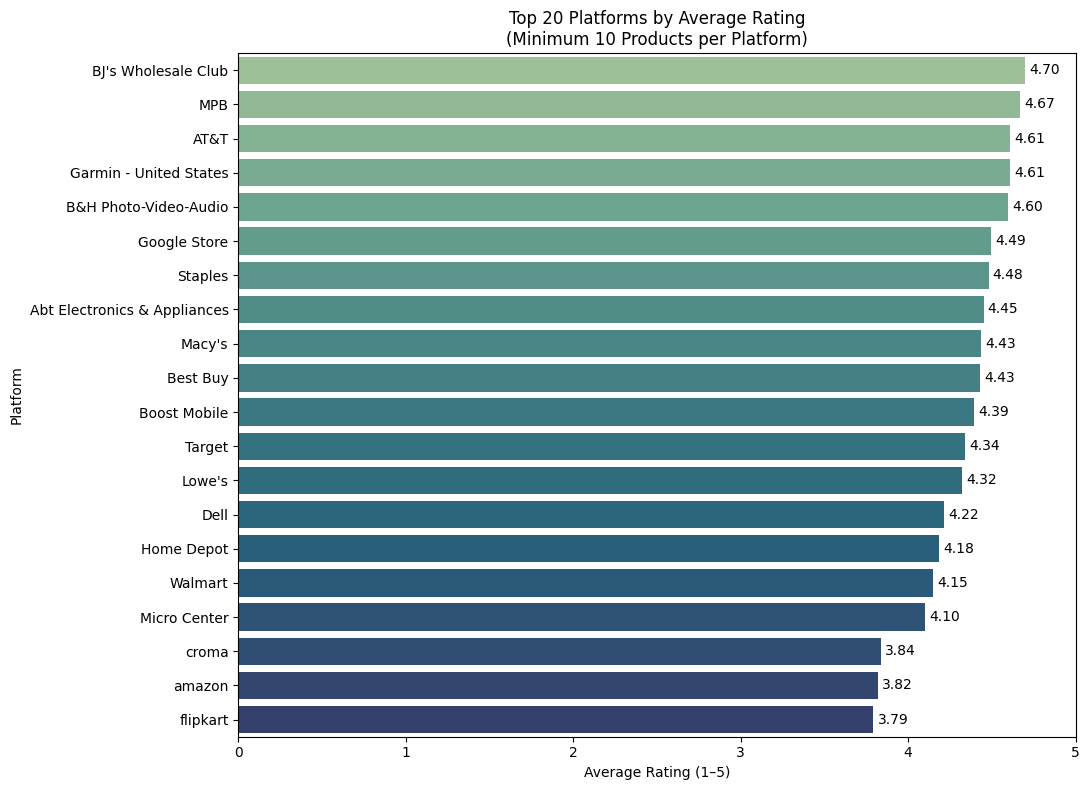

In [ ]:
platform_rating_stats = (
    df_db.groupby('platform')
    .agg(
        average_rating=('rating', 'mean'),
        product_count=('rating', 'size')
    )
    .query('product_count >= 10')
    .nlargest(20, 'average_rating')
)

plt.figure(figsize=(11, 8))

ax = sns.barplot(
    data=platform_rating_stats,
    x='average_rating',
    y='platform',
    hue='platform',
    palette='crest',
    legend=False
)

ax.set(
    title='Top 20 Platforms by Average Rating\n'
          '(Minimum 10 Products per Platform)',
    xlabel='Average Rating (1–5)',
    ylabel='Platform',
    xlim=(0, 5)
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

## 5. Visibility & Ranking

This section analyzes how visible products are (measured by `popularity_score`) and its connection to user ratings and customer reviews.

In [ ]:
# Calculate Visibility & Ranking KPIs
avg_rating_val = df_db['rating'].mean()
avg_visibility_val = df_db['popularity_score'].mean()

print(f"Average Rating: {avg_rating_val:.2f}")
print(f"Average Visibility Score: {avg_visibility_val:.2f}")

Average Rating: 4.08
Average Visibility Score: 32.86


### Ranking Distribution
We visualize how visibility scores are distributed across all catalog products.

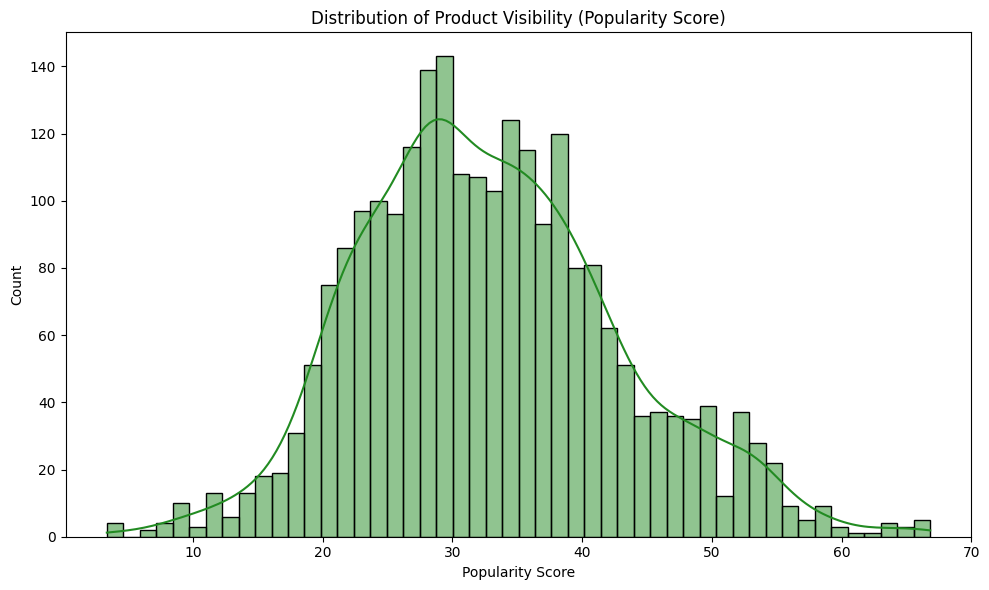

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_db['popularity_score'], bins=50, kde=True, color='forestgreen')
plt.title('Distribution of Product Visibility (Popularity Score)')
plt.xlabel('Popularity Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Rating vs. Ranking
We look for correlations between how well a product is rated by users versus its placement or visibility score.

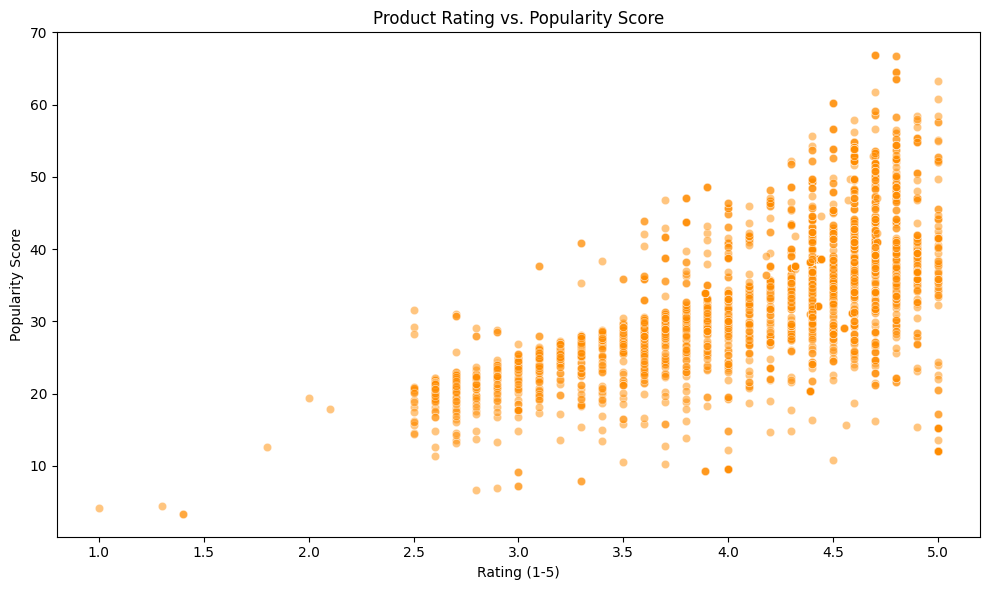

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_db, x='rating', y='popularity_score', alpha=0.5, color='darkorange')
plt.title('Product Rating vs. Popularity Score')
plt.xlabel('Rating (1-5)')
plt.ylabel('Popularity Score')
plt.tight_layout()
plt.show()

### Reviews vs. Ranking (Bubble Chart)
We plot the number of reviews against the popularity score, using product prices to determine the bubble sizes.

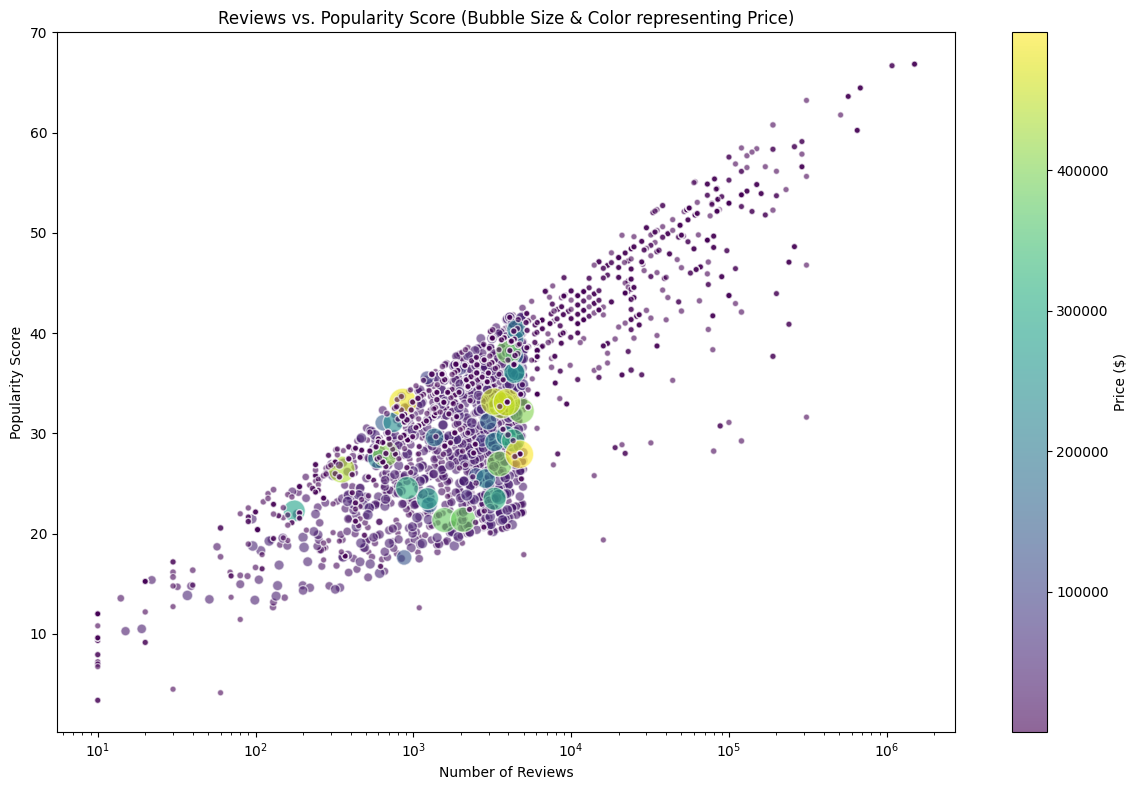

In [ ]:
plt.figure(figsize=(12, 8))
# Limit maximum size scaling so outliers do not skew the bubbles too heavily
sizes = df_db['price']
sizes_scaled = ((sizes - sizes.min()) / (sizes.max() - sizes.min()) * 400) + 20

bubble_plot = plt.scatter(
    data=df_db,
    x='reviews',
    y='popularity_score',
    s=sizes_scaled,
    c='price',
    cmap='viridis',
    alpha=0.6,
    edgecolors='w'
)

plt.title('Reviews vs. Popularity Score (Bubble Size & Color representing Price)')
plt.xlabel('Number of Reviews')
plt.ylabel('Popularity Score')
plt.xscale('log')
cbar = plt.colorbar(bubble_plot)
cbar.set_label('Price ($)')
plt.tight_layout()
plt.show()

## 6. Product Explorer

This interactive section presents key performance indicators alongside a detailed database explorer table.

In [ ]:
# Calculate and display KPI metrics for the filtered explorer view
total_prod_explorer = len(df_db)
avg_price_explorer = df_db['price'].mean()
avg_rating_explorer = df_db['rating'].mean()

print(f"=== Product Explorer Metrics ===")
print(f"Total Products: {total_prod_explorer}")
print(f"Average Price: {avg_price_explorer:.2f}")
print(f"Average Rating: {avg_rating_explorer:.2f} / 5.0")

=== Product Explorer Metrics ===
Total Products: 2392
Average Price: 16639.26
Average Rating: 4.08 / 5.0


### Explorer Table
Below are the details for the products in the dataset.

In [ ]:
# Define the columns we want to display
columns_to_show = ['title', 'brand', 'price', 'rating', 'reviews', 'platform']
if 'discount' in df_db.columns:
    columns_to_show.append('discount')

# Display the top 50 records for catalog exploration
display(df_db[columns_to_show].head(50))

,title,brand,price,rating,reviews,platform,discount
0,Nike air fryer India Model 114,Nike,509.0,3.8,3324,reliance digital,0
1,Philips microwave oven convection Model 363,Philips,545.0,4.5,3336,reliance digital,0
2,Dell air fryer India Model 406,Dell,580.0,5.0,4288,reliance digital,0
3,Nike power bank fast charging Model 363,Nike,702.0,4.5,1477,flipkart,0
4,Samsung men running shoes Model 836,Samsung,712.0,4.6,819,flipkart,0
5,Samsung power bank fast charging Model 308,Samsung,780.0,2.9,2239,croma,0
6,Philips microwave oven convection Model 889,Philips,861.0,5.0,1382,amazon,0
7,Puma power bank fast charging Model 343,Puma,889.0,4.9,3557,reliance digital,0
8,Philips air fryer India Model 575,Philips,1010.0,3.3,2030,flipkart,0
9,HP microwave oven convection Model 801,HP,1014.0,4.8,556,flipkart,0
